In [103]:
import numpy as np
from scipy.integrate import solve_bvp
from scipy.interpolate import RBFInterpolator
import pandas as pd
import matplotlib.pyplot as plt


# Set up w and dw for variable current

In [104]:
def rbf_gradient(interp, x):
    x = np.atleast_2d(x)
    x_norm = (x - interp._shift) / interp._scale
    y_norm = (interp.y - interp._shift) / interp._scale
    coeffs = interp._coeffs.ravel()

    diff = x_norm[:, None, :] - y_norm[None, :, :]     # (M, N, d) normalized
    r    = np.sqrt(np.sum(diff**2, axis=-1))            # (M, N)

    with np.errstate(divide='ignore', invalid='ignore'):
        factor = np.where(r == 0.0, 0.0, 2 * np.log(np.where(r == 0, 1, r)) + 1)

    kernel_grad = factor[:, :, None] * diff             # (M, N, d) w.r.t. x_norm
    grad = np.einsum('mnd,n->md', kernel_grad, coeffs[:len(y_norm)])

    poly_coeffs = coeffs[len(y_norm):]
    # divide EVERYTHING by scale (chain rule through normalization)
    return (grad + poly_coeffs[1:]) / interp._scale     # (M, d)

In [105]:
all_data = pd.read_csv('data/green_bay_wind_snapshot.csv')

X, Y, theta, speed = all_data['lon'], all_data['lat'], np.deg2rad(all_data['waveMeanDirection'].to_numpy()), 1 / all_data['waveTp'].to_numpy()

u, v = speed * np.sin(theta), speed * np.cos(theta)

# coordinates
y = np.column_stack([X, Y])

u_interp = RBFInterpolator(y, u, kernel="thin_plate_spline", smoothing=0.0)
v_interp = RBFInterpolator(y, v, kernel="thin_plate_spline", smoothing=0.0)

In [106]:
def w(s):
    return 2*np.vstack([u_interp(s), v_interp(s)])

def dw(s):
    grad_u = rbf_gradient(u_interp, s)
    grad_v = rbf_gradient(v_interp, s)
    return 2*np.array([grad_u.T, grad_v.T])

def ode(t, Y, p):
    v = 10
    T = p[0]
    x, y, l1, l2 = Y
    lnorm = np.sqrt(l1**2 + l2**2) + 1e-10

    u1 = v * l1 / lnorm
    u2 = v * l2 / lnorm

    s = np.column_stack([x, y]) 
    w1, w2 = w(s)
  
    dx = T * (u1 + w1)
    dy = T * (u2 + w2)

    Dw = dw(s)
    # print(Dw.shape)
    # dl1, dl2 = -T * (Dw.T @ np.array([l1, l2]))

    lam = np.array([l1, l2])
    dl1, dl2 = -T * np.einsum('jin,jn->in', Dw, lam)

    return np.array([dx, dy, dl1, dl2])

def solve(x0, xf):

    def bc(ya, yb, p):
        T = p[0]
        v=10

        xa, ya, l1a, l2a = ya
        xb, yb, l1b, l2b = yb

        lam_norm = np.sqrt(l1b**2 + l2b**2) + 1e-10
        u1b = v * l1b / lam_norm
        u2b = v * l2b / lam_norm

        sb = np.array([xb, yb])[None, :]
        wb = w(sb).squeeze(1)
        
        Hf = l1b * (u1b + wb[0]) + l2b * (u2b + wb[1]) - 1.0

        return np.array([
            xa - x0[0],
            ya - x0[1],
            xb - xf[0],
            yb - xf[1],
            Hf
        ])

    t = np.linspace(0, 1, 100)

    # initial guess
    Y_guess = np.zeros((4, t.size))
    Y_guess[0] = np.linspace(x0[0], xf[0], t.size)
    Y_guess[1] = np.linspace(x0[1], xf[1], t.size)
    Y_guess[2] = 1.0
    Y_guess[3] = 1.0

    p_guess = np.array([2.0])

    sol = solve_bvp(ode, bc, t, Y_guess, p=p_guess)

    return sol

In [107]:
x0 = np.array([-87.375, 45.20])     # Chambers Island
xf = np.array([-87.614, 45.108])    # Finish

sol = solve(x0, xf)

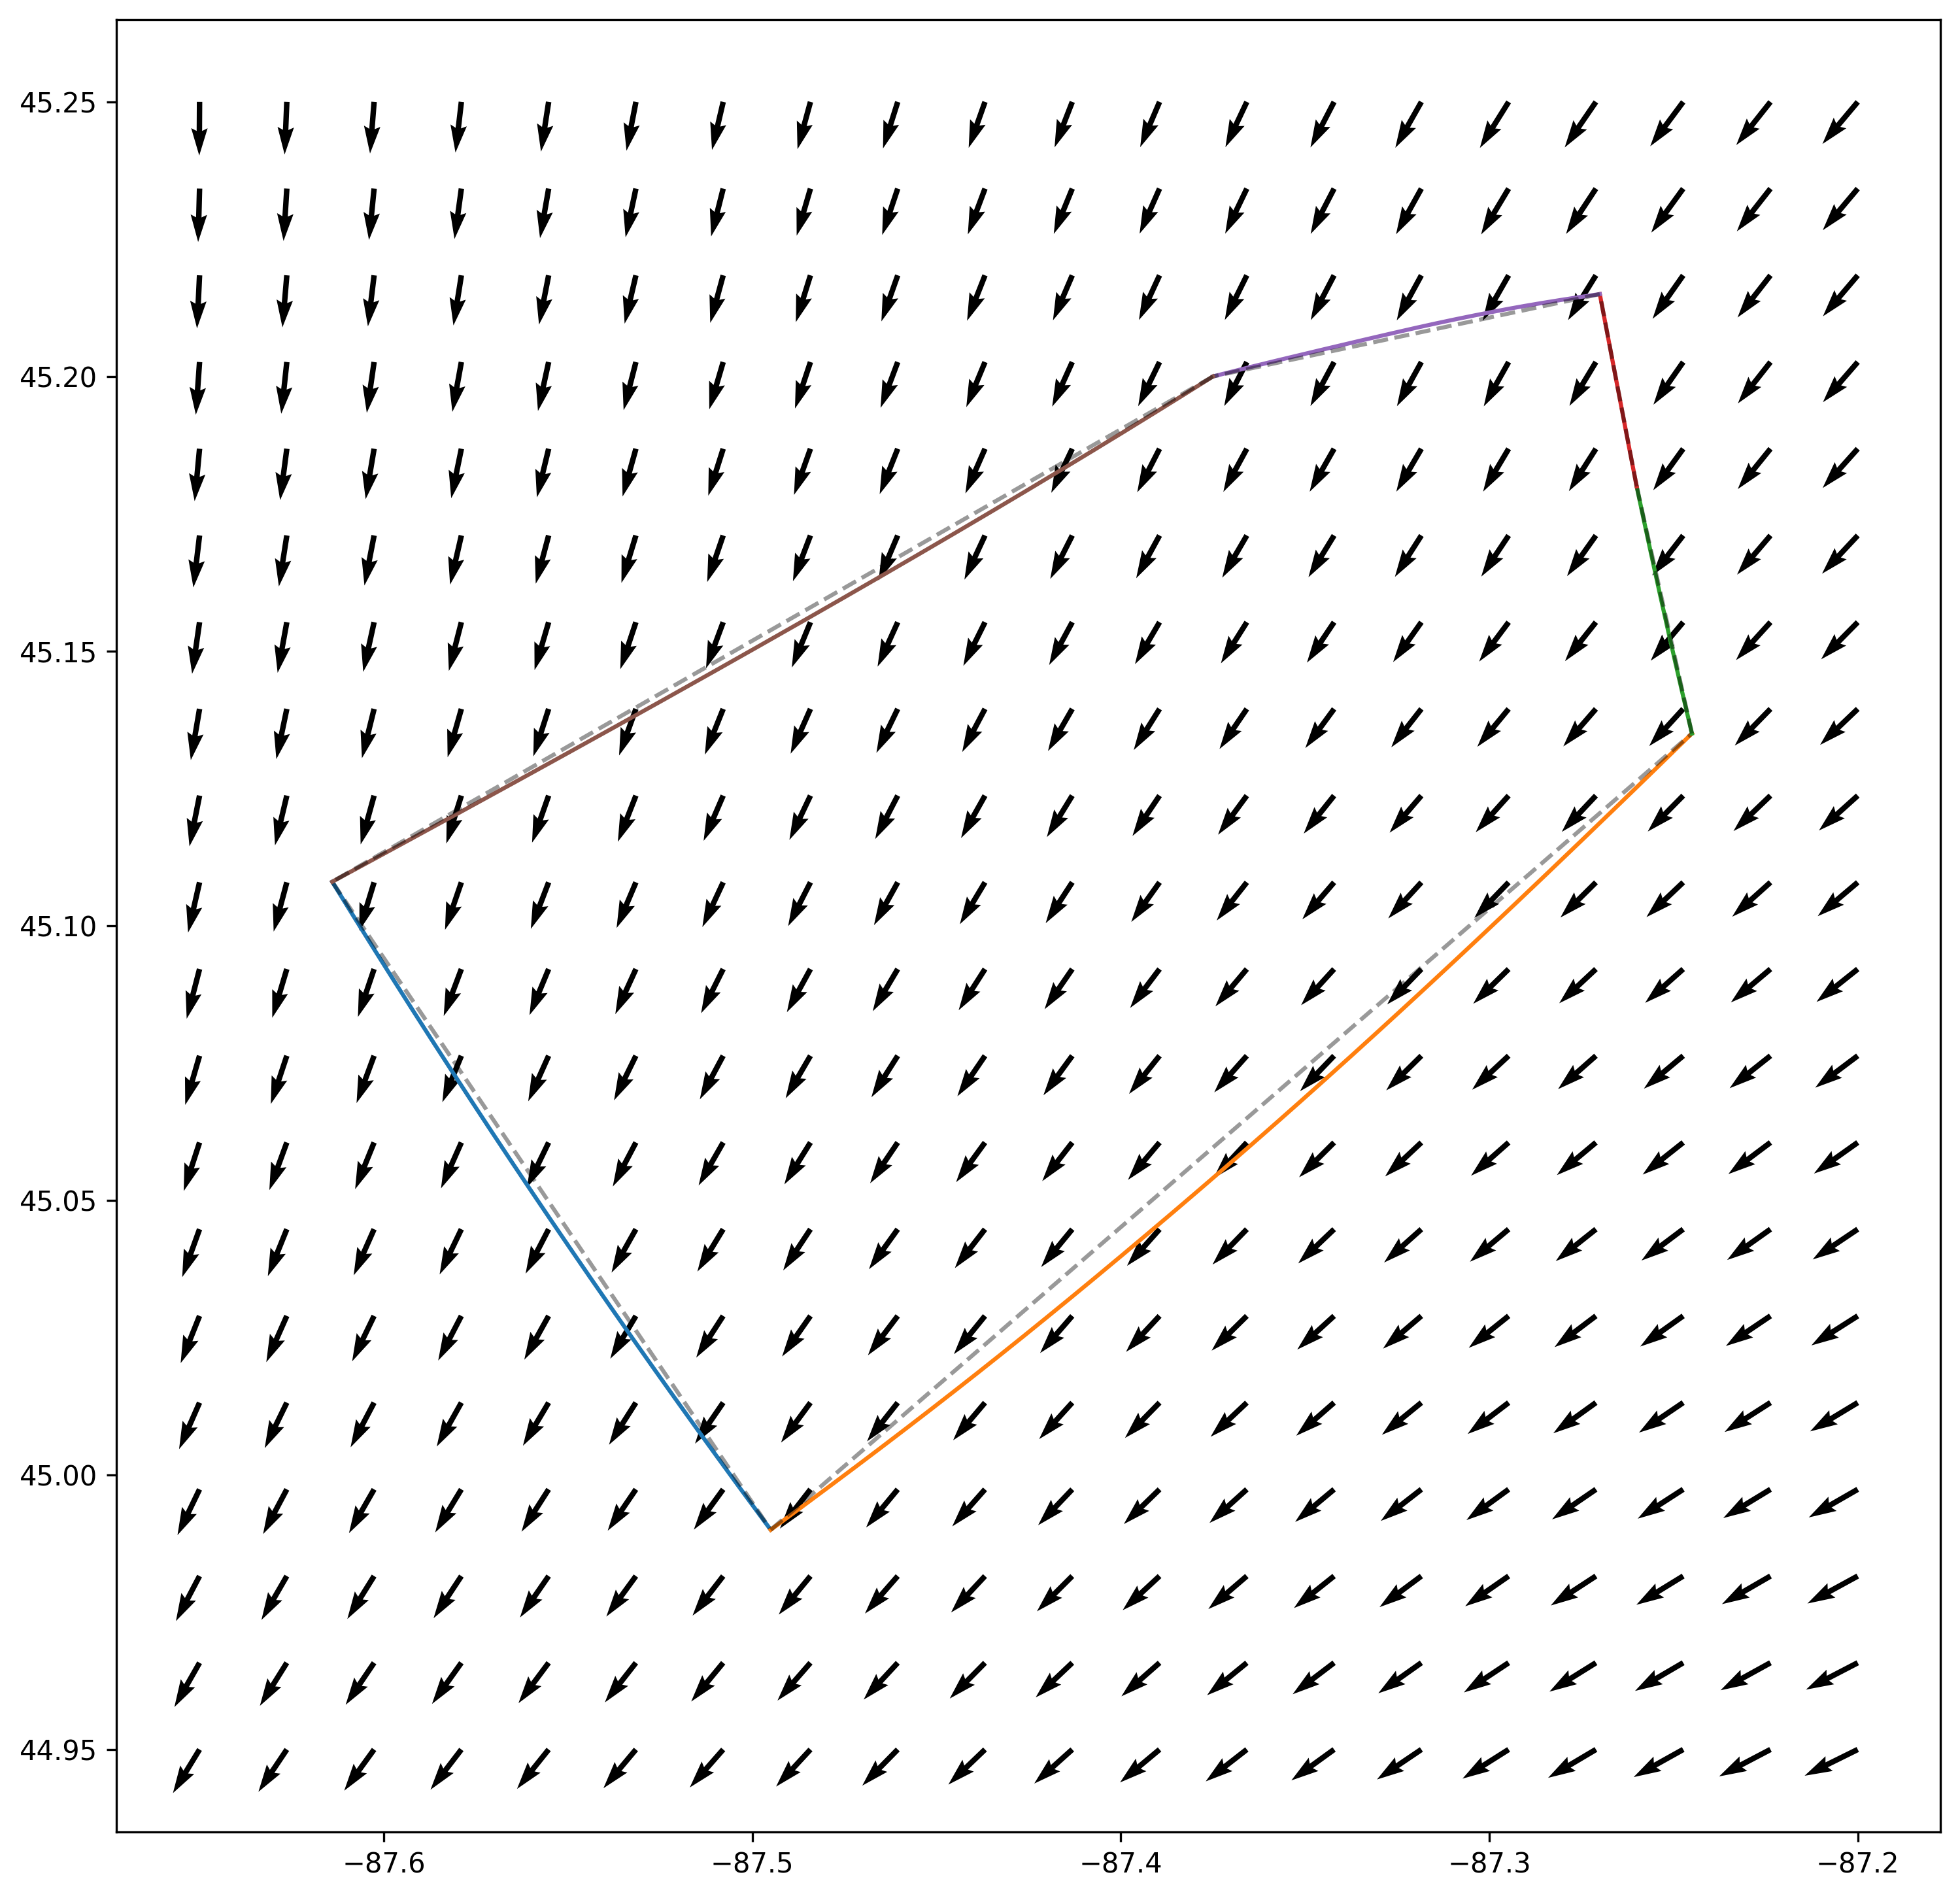

In [110]:
OFFICIAL = [
    (-87.614, 45.108),   # Start
    (-87.495, 44.990),   # Green Island
    (-87.245, 45.135),   # Fish Creek
    (-87.260, 45.180),   # Strawberry S
    (-87.270, 45.215),   # Strawberry N
    (-87.375, 45.200),   # Chambers Island
    (-87.614, 45.108),   # Finish
]

fig, ax = plt.subplots(figsize=(12, 12), dpi=300)

for leg in range(6):
    x0, x1 = np.array(OFFICIAL[leg]), np.array(OFFICIAL[leg+1])
    sol = solve(x0, x1)

    ax.plot(sol.y[0], sol.y[1])
    ax.plot([x0[0], x1[0]], [x0[1], x1[1]], 'k--', alpha=.4)

X, Y = np.meshgrid(np.linspace(-87.65, -87.2, 20), np.linspace(44.95, 45.25, 20))
S = np.vstack([X.ravel(), Y.ravel()]).T
U, V = w(S)
U, V = U.reshape(X.shape), V.reshape(Y.shape)

ax.quiver(X, Y, U, V)

plt.show()